# <b>lec05. 딥러닝 CNN - cat& dog 이미지 분류
* https://www.kaggle.com/c/dogs-vs-cats

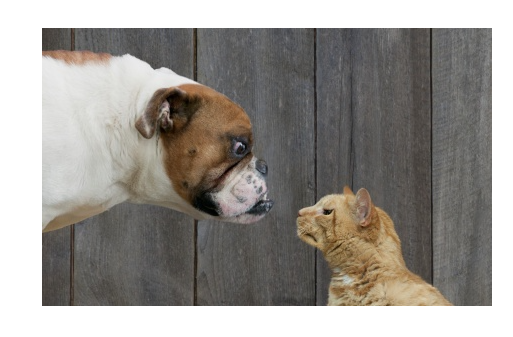

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D #CNN
from tensorflow.keras.layers import  Flatten, Rescaling #일반 딥러닝

from tensorflow.keras.initializers import GlorotNormal #Xavier가 GlorotNormal로 바뀜
from tensorflow.keras.applications import MobileNetV2  #최소 이미지 크기 (32*32)

#----------------------------------------------------------------------------------  랜덤 시드 고정
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  EDA : 이미지로드
from tensorflow.keras.utils import load_img
from PIL import Image
from tensorflow.keras.utils import image_dataset_from_directory

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b> DATA load

In [2]:
import os
img_ext = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp') #우리는 다 jpg
img_list = [
    os.path.join('./dataset/catdog/train/cat/', f)
    for f in os.listdir('./dataset/catdog/train/cat/')
    if f.lower().endswith(img_ext)
]
print(  len(img_list) )
print(img_list[:10])

301
['./dataset/catdog/train/cat/cat.0.jpg', './dataset/catdog/train/cat/cat.1.jpg', './dataset/catdog/train/cat/cat.10.jpg', './dataset/catdog/train/cat/cat.100.jpg', './dataset/catdog/train/cat/cat.101.jpg', './dataset/catdog/train/cat/cat.102.jpg', './dataset/catdog/train/cat/cat.103.jpg', './dataset/catdog/train/cat/cat.104.jpg', './dataset/catdog/train/cat/cat.105.jpg', './dataset/catdog/train/cat/cat.106.jpg']


# EDA

## PIL

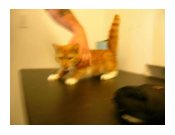

In [3]:
from PIL import Image #픽셀이 아닌 사진
plt.figure(figsize = (2,2))
img = Image.open("./dataset/catdog/train/cat/cat.0.jpg")
plt.imshow(img)
plt.grid(False)
plt.axis(False)
plt.show()

## keras.utils.load_img()

```python
keras.utils.load_img(
    path,
    color_mode="rgb",
    target_size=None,
    interpolation="nearest",
    keep_aspect_ratio=False,
)

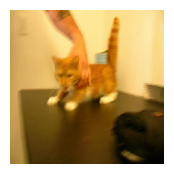

In [4]:
from tensorflow.keras.utils import load_img
plt.figure(figsize = (2,2))
img = load_img('./dataset/catdog/train/cat/cat.0.jpg',  target_size=(150,150)) # 원본 사진의 크기가 제각각인데 load하면 다 사이즈 맞춰짐
plt.imshow(img)
plt.grid(False)
plt.axis(False)
plt.show()

## keras.utils.image_dataset_from_directory()
* https://keras.io/api/data_loading/image/

<pre>
main_directory/                   C:\IT\workspace_ptyhon\dl\dataset\catdog\train
class_a/                                cat
...a_image_1.jpg
...a_image_2.jpg
class_b/                                dog
...b_image_1.jpg
...b_image_2.jpg
이런구조여야 사용가능

``` python
keras.utils.image_dataset_from_directory(
    directory,           #메인디렉토리
    labels="inferred",   #별도 라벨 불필요 = 라벨을 자동으로 추론
    label_mode="int",    # 라벨을 어떤 형태로 만드는지
                         # (int) sparse_categorical_crossentropy 라벨 정수형태, 닫중분류에서 많이 사용
                         #(categorical)categorical_crossentropy
                         # (binary) binary_crossentropy
    class_names=None,    # 학습 데이터 = None이면 main_directory내 모든 폴더 
    batch_size=32,       # 한 번에 모델에 넣는 이미지 수 
                         # 크다 == 학습속도 빠름 == 정확도 떨어짐
                         # 작다 == 학습속도 느림 == 정확도 올라감
    image_size=(256, 256),
    shuffle=True,        # 데이터 랜덤 섞기 = 모델 과적합 방지
    seed=None,           # 랜덤 고정값
    validation_split=None, #학습 / 검증 데이터 나누기

    color_mode="rgb",
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


In [5]:
train_dir = image_dataset_from_directory("./dataset/catdog/train"
                            ,image_size=(150, 150),  seed=4894
                            ,validation_split=0.2
                            , batch_size=32
                            , subset="training"
                            , label_mode = "binary")


val_dir = image_dataset_from_directory("./dataset/catdog/train"
                            ,image_size=(150, 150),  seed=4894
                            ,validation_split=0.2
                            , batch_size=32
                            , subset="validation"
                            , label_mode = "binary")


Found 602 files belonging to 2 classes.
Using 482 files for training.
Found 602 files belonging to 2 classes.
Using 120 files for validation.


# 모델

In [6]:
model = Sequential([
    Rescaling(1.0/255.0, input_shape=(150,150,3)), # ---- 전처리 가공(스케일링)

    #----------------------- ---------------------CNN
    Conv2D (filters = 16, kernel_size = (5,5), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)), 
    Conv2D (filters = 32, kernel_size = (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D (filters = 64, kernel_size = (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten( ),                                     # --------------- 평탄화작업
    Dense(256 , activation = "relu"),               # ------------ hidden layer 3
    Dense(1  , activation = "sigmoid")                # ------------ output layer 
])
model.compile(loss ="binary_crossentropy", optimizer = "adam", metrics=["accuracy"]) 

In [7]:
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 146, 146, 16)        │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 73, 73, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 71, 71, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 35, 35, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 33, 33, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       4,194,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,219,169 (16.09 MB)

 Trainable params: 4,219,169 (16.09 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
fit_res = model.fit( train_dir, epochs=10, validation_data = val_dir )
loss, acc = model.evaluate(val_dir)
print(f"acc : {acc:.4f} , loss:{loss:.4f}")

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.4855 - loss: 0.7658 - val_accuracy: 0.5500 - val_loss: 0.6907
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.4938 - loss: 0.6929 - val_accuracy: 0.5500 - val_loss: 0.6869
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6432 - loss: 0.6814 - val_accuracy: 0.5750 - val_loss: 0.6818
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5498 - loss: 0.6768 - val_accuracy: 0.5583 - val_loss: 0.6749
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.6411 - loss: 0.6329 - val_accuracy: 0.5000 - val_loss: 0.7433
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.6680 - loss: 0.6127 - val_accuracy: 0.5667 - val_loss: 0.6903
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7469 - loss: 0.5276 - val_accuracy: 0.5417 - val_loss: 0.8095
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7656 - loss: 0.5019 - val_accuracy: 0.6833 - v

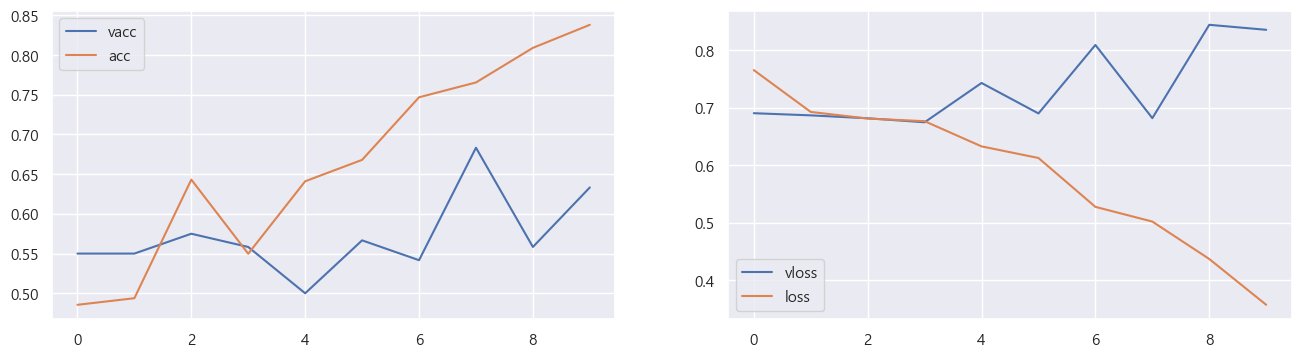

In [9]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = fit_res.history["val_accuracy"]
acc  = fit_res.history["accuracy"]
plt.plot(range(10), vacc , label="vacc")
plt.plot(range(10), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = fit_res.history["val_loss"]
loss = fit_res.history["loss"]
plt.plot(range(10),vloss , label="vloss")
plt.plot(range(10),loss  , label="loss")
plt.legend()
plt.show()

학습이 잘 안됨ㅎㅋ

# <font color=red><b>전이학습
* <b>ILSVRC(ImageNet Large Scale Visual Recognition Challenge)</b>
    - Train : 약 128만 장
    - Validation : 5만 장
    - Test : 10만 장
    - 총 클래스 : 1000개
    - https://www.image-net.org/challenges/LSVRC/
* <b>전이학습</b>
    - 잘 알려진 모델을 가져와 내 데이터에 맞게 모델을 튜닝(=가중치 보정)해서 학습하는 것
    - 적은 데이터셋 학습에 효율적
    - https://keras.io/api/applications/mobilenet/mobilenet_models/#mobilenetv2-function

![image](https://blog.kakaocdn.net/dn/OzIUv/btrs8AsKuH8/OHHLKL2orZNqyaoCzuckJ0/img.png)

```python
keras.applications.MobileNetV2(
    input_shape=None,                 # (150*150)
    weights="imagenet",               #ILSVRC공모전 제출 당시의 w값

    include_top=False,                #Flatten()이후 직접 구성
    
    include_top=True,                 # FC(평탄화)그대로 사용
    classes=1000,                     # 1000종
    classifier_activation="softmax",  # 다중분류
    
        
    alpha=1.0,
    input_tensor=None,
    pooling=None,
    name=None,
)


## <font color = blue><b>include_top = True

In [10]:
mobile_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=True)

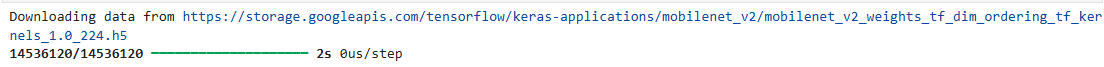

In [11]:
#mobile_model.summary()

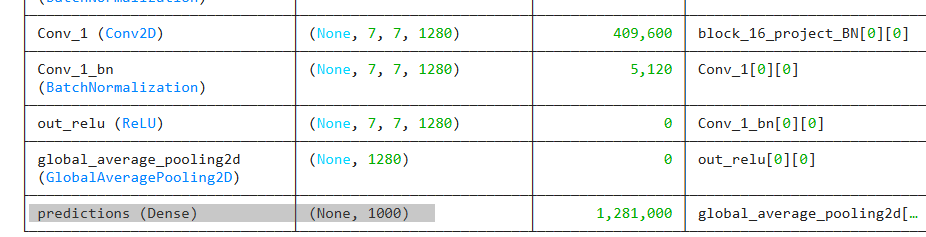

## <font color = blue><b>include_top = False

In [12]:
mobile_model = MobileNetV2(
    input_shape=(150,150,3),
    include_top=False)

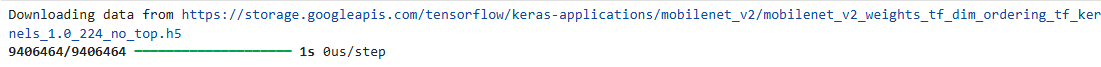

In [13]:
#mobile_model.summary()

In [14]:
mobile_model.trainable = True

* <font color = red><b> 상당수 레이어의 w를 보정, 그러나 시간상 20레이어 w만 보정

In [15]:
for layer in mobile_model.layers[:140]: #그림의 흰부분(W그대로)
    layer.trainable = False

for layer in mobile_model.layers[140 : ]:#그림의 파란부분(W변경)
    layer.trainable = True

In [16]:
model = Sequential([
    Rescaling(1.0/255.0, input_shape=(150,150,3)), # ---- 전처리 가공(스케일링)

    #----------------------- ---------------------MobileNetV2
    mobile_model,
    
    Flatten( ),                                     # --------------- 평탄화작업
    Dense(256 , activation = "relu"),               # ------------ hidden layer 3
    Dense(1  , activation = "sigmoid")                # ------------ output layer 
])
model.compile(loss ="binary_crossentropy", optimizer = "adam", metrics=["accuracy"]) 

fit_res = model.fit( train_dir, epochs=10, validation_data = val_dir )
loss, acc = model.evaluate(val_dir)
print(f"acc : {acc:.4f} , loss:{loss:.4f}")

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - accuracy: 0.8589 - loss: 1.2799 - val_accuracy: 0.8417 - val_loss: 7.7458
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step - accuracy: 0.9544 - loss: 0.3454 - val_accuracy: 0.9500 - val_loss: 2.3428
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step - accuracy: 0.9564 - loss: 0.1367 - val_accuracy: 0.9583 - val_loss: 2.1830
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.9253 - loss: 0.2543 - val_accuracy: 0.9333 - val_loss: 3.1610
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 260ms/step - accuracy: 0.9730 - loss: 0.1732 - val_accuracy: 0.9417 - val_loss: 4.0609
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 258ms/step - accuracy: 0.9647 - loss: 0.1349 - val_accuracy: 0.9667 - val_loss: 1.4486
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step - accuracy: 0.9917 - loss: 0.0304 - val_accuracy: 0.9250 - val_loss: 3.6233
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 259ms/step - accuracy: 0.9959 - loss: 0.0456 - val_accuracy: 0.

# <font color = red><b>조기종료

# --------------------------

In [ ]:
(x_train, y_train), (x_test, y_test) = load_data(path="mnist.npz")
# assert x_train.shape == (60000, 28, 28)
# assert x_test.shape == (10000, 28, 28)
# assert y_train.shape == (60000,)
# assert y_test.shape == (10000,)

In [ ]:
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

# 타겟피쳐

In [ ]:
print(y_train[:10])
plt.figure(figsize=(5,2))
pd.Series(y_train).value_counts().plot(kind = "bar")
plt.show()

In [ ]:
print(y_test[:10])
plt.figure(figsize=(5,2))
pd.Series(y_test).value_counts().plot(kind = "bar")
plt.show()

# data set

In [ ]:
#x_train[0]

# <b> EDA

In [ ]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])
plt.title(y_train[0])
plt.show()

In [ ]:
fig, axes = plt.subplots(3,10, figsize=(20,6))
for i, px_arr in enumerate(x_train[170:200]) : 
    row = i // 10
    col = i % 10
    axes[row][col].imshow(px_arr)
    axes[row][col].set_title(y_train[170:200][i])
    # Hide axes,grid
    axes[row][col].grid(False)
    axes[row][col].set_xticks([])
    axes[row][col].set_yticks([])
plt.show()

# <b> 전처리 & 가공
* 픽셀 (RGB : 0 ~ 255) 스케일링 : MinMaxScaler
* 컬러, 노이즈, 채도 조절 : OpenCV
* 이미지 증강(Augmentation)

## 스케일링 : MinMaxScaler
* /255 : 픽셀(0 ~ 255) -> (0 ~ 1)
* 신경망이 학습하기 쉬워짐

In [ ]:
x_train = x_train /255
x_test = x_test /255

## 흑백처리 - 지금 안하긴함

In [ ]:
th = 0.5
x_trian_bin = np.where(x_train>th, 1.0, 0.0)
x_test_bin  = np.where(x_test >th, 1.0, 0.0)
plt.figure(figsize=(6,1))

plt.subplot(1,2,1)
plt.imshow(x_trian_bin[0].reshape(28,28), cmap='gray')
plt.grid(False)
plt.title("보정처리")

plt.subplot(1,2,2)
plt.imshow(x_train[0].reshape(28,28), cmap='gray')
plt.grid(False)
plt.title("원본")

plt.show()

# <b> 모델 -ML DL

## <b> ML

In [ ]:
x_train[0].shape, x_train[0].reshape(1, 784).shape

In [ ]:
x_train.reshape(60000, -1).shape #-1은 자동으로 계산

In [ ]:
model = DecisionTreeClassifier(random_state =4545)
model.fit(x_train.reshape(60000, -1), y_train)
pred = model.predict(x_test.reshape(10000, -1))
accuracy = accuracy_score(y_test, pred)
print(f"accuracy : {accuracy:.4f}")

## <b> DL

In [ ]:
model = Sequential([
    Dense(10 , activation = "relu" , input_dim=784), # ------------ input layer
    Dense(16 , activation = "relu"),               # ------------ hidden layer 3
    Dense(24 , activation = "relu"),
    Dense(8  , activation = "relu"),
    Dense(10  , activation = "softmax")                # ------------ output layer 
])
model.compile(loss ="sparse_categorical_crossentropy", optimizer = "adam", metrics=["accuracy"]) 

In [ ]:
model.summary() 

In [ ]:
X80 = x_train.reshape(60000, -1)
y80 = y_train
X20 = x_test.reshape(10000, -1)
y20 = y_test
res = model.fit(X80, y80,  epochs=20, validation_data = (X20, y20))
loss, acc = model.evaluate(X20, y20)
print(f"acc : {acc:.4f} , loss:{loss:.4f}")

In [ ]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(20), vacc , label="vacc")
plt.plot(range(20), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()
plt.show()

강사님이랑 그래프 다른 이유 = 가중치가 다름<br>
모델 여러번 돌리면 학습 여러번이라 del model하고 다시 모델해서 학습하면댐

### 오답 체크

In [ ]:
proba = model.predict(X20) # 각 숫자 확률
pred = np. argmax(proba, axis = 1) # 확률 가장 큰 숫자 선택
pred

In [ ]:
pred.shape, y_test.shape

In [ ]:
from sklearn.metrics import confusion_matrix # confusion_matrix(실제값, 예측값)을 비교해서 어떤걸 맞추고 틀렷는지 표로 보여줌

cm = confusion_matrix(y_test, pred)
print(cm)


In [ ]:
cmdf = pd.DataFrame(cm)
for i in range(10):
    cmdf.iloc[i,i] = 0   #---- 대각방향 정답 (정답빼고 오답만 보자)

plt.figure(figsize=(6,4))
sns.heatmap(cmdf, cmap="Reds", fmt='d', annot=True)
plt.show()

In [ ]:
oxdf = pd.DataFrame( {"y":y_test, "pred" : pred}) #oxdf.shape : 전체 실제값.예측값 표 크기
# idx = oxdf [oxdf['y'] != oxdf['pred']].index
# xdf = oxdf.loc[idx, : ] # xdf.shape : 틀린것만 모은 표 크기
# print (xdf.shape)
oxdf.shape

In [ ]:
oxdf = pd.DataFrame({"y": y_test, "pred": pred}) # oxdf : 전체 실제값, 예측값 오답이 섞인거
oxdf["img"] = list( x_test.reshape(10000,-1)) #(x_test)해서[(28*28)]도가능
print(oxdf.shape)
oxdf.head(1)


In [ ]:
xdf = oxdf[oxdf['y'] != oxdf['pred']] # xdf : 틀린것만 모은 데이터
print(xdf.shape)
xdf.head(1)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

oxdf = pd.DataFrame( { "y":y_test, "pred":pred } )
wrong_index = oxdf[  oxdf['y'] != oxdf['pred']  ].index
wrong_index.shape      # y_test - 10,000개 중 616개 틀림


# Numpy 배열 인덱싱으로 오답 이미지와 예측 정보만 끄집어냅니다.
# 배열 이름[인덱스 리스트] 문법을 사용하여 깔끔하게 처리합니다.
x_test_wrong = x_test[wrong_index]
y_test_wrong = y_test[wrong_index]
pred_wrong = pred[wrong_index]

# --- 2. 최적화된 시각화 설정 ---
rows, cols = 5, 6 # 5x6 그리드로 더 많은 이미지 확인
plt.figure(figsize=(9,7.5)) # 전체 피겨 크기

# 서브플롯 간의 여백을 수동으로 세밀하게 조정합니다.
# wspace: 가로 간격, hspace: 세로 간격 (0에 가까울수록 딱 붙음)
plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.01, wspace=0.1, hspace=0.25)

plt.suptitle("Misclassified Digits Analysis True(False)", fontsize=20, fontweight='bold', y=0.96)

# 오답 데이터셋(x_test_ox 등)에서 Top 25개만 순회
for i in range(rows * cols):
    if i >= len(x_test_wrong): break # 오답이 25개 미만일 경우 방지
    
    plt.subplot(rows, cols, i + 1)
    
    # 이미지 데이터는 원본 배열(x_test_ox)에서 바로 가져옵니다.
    # 784차원으로 펼쳐져 있다면 다시 (28, 28)로 리셰이프해야 사진으로 보입니다.
    img_data = x_test_wrong[i].reshape(28, 28)
    plt.imshow(img_data, cmap='gray')
    
    # 원본 데이터 인덱스와 오답 정보를 제목에 깔끔하게 표시
    origin_idx = wrong_index[i]
    plt.title(f"{y_test_wrong[i]} ({pred_wrong[i]})", 
              fontsize=14, color='red', fontweight='bold'
              if y_test_wrong[i] != pred_wrong[i] else 'black')
    plt.axis('off') # 축 눈금 제거

# plt.tight_layout()#은 사용하지 않거나, 
plt.tight_layout(rect=[0, 0, 1, 0.97]) #처럼 rect 옵션을 줘서 suptitle과 겹침을 방지합니다.
plt.show() ;

In [ ]:
print(xdf.shape)

# <font color=red><b> 모델 -CNN

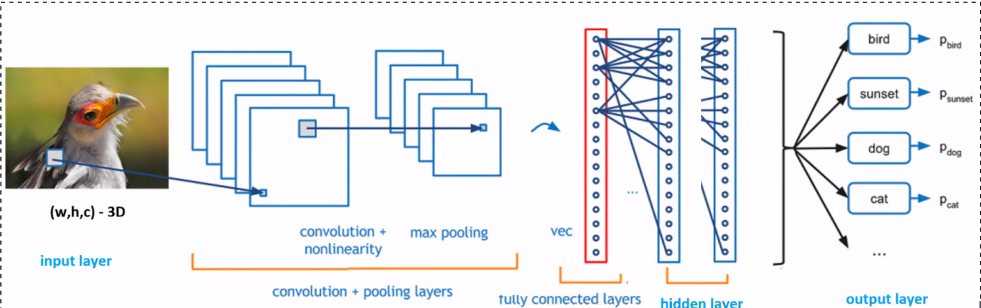

## CNN모델

* https://keras.io/api/layers/convolution_layers/convolution2d/
* https://keras.io/api/layers/pooling_layers/max_pooling2d/
* https://keras.io/api/layers/reshaping_layers/flatten/
* https://keras.io/api/layers/core_layers/dense/

```python
keras.layers.Conv2D(
    filters,
    kernel_size,
    strides=(1, 1),
    padding="valid",
    data_format=None,
    dilation_rate=(1, 1),
    groups=1,
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform",
    bias_initializer="zeros",
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    **kwargs
)


keras.layers.MaxPooling2D(
    pool_size=(2, 2), strides=None, padding="valid", data_format=None, name=None, **kwargs
)

keras.layers.Flatten(data_format=None, **kwargs)


keras.layers.Dense(
    units,
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform",
    bias_initializer="zeros",
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    lora_rank=None,
    lora_alpha=None,
    quantization_config=None,
    **kwargs
)


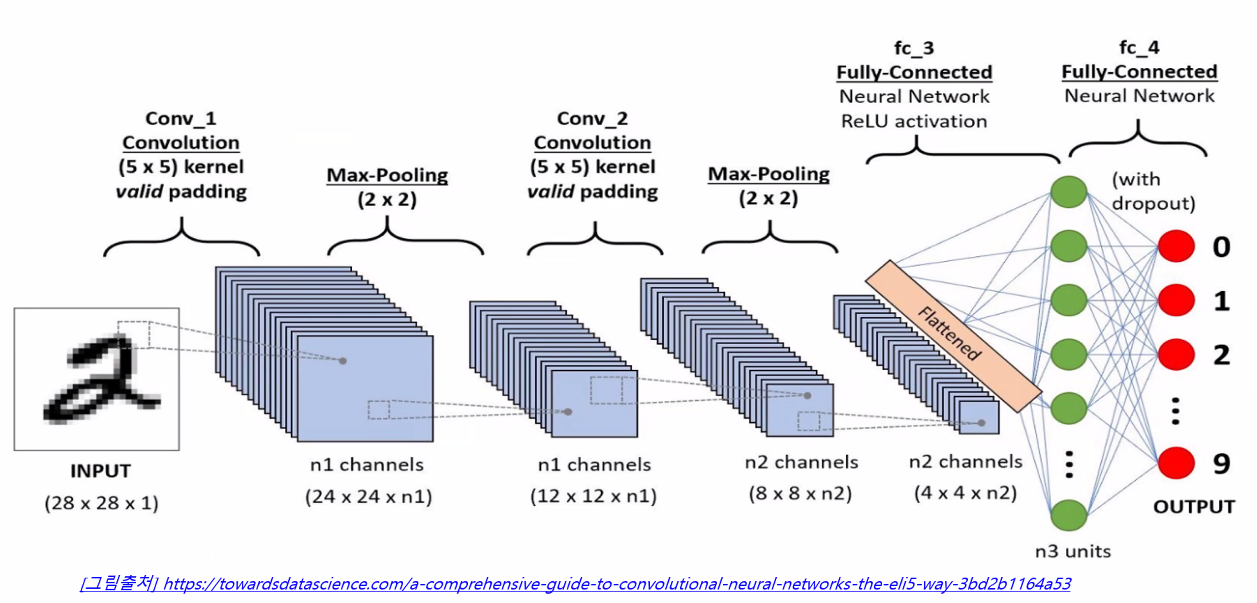

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
model = Sequential([


    Conv2D (filters = 16, kernel_size = (5,5), activation="relu", input_shape=(28,28,1)), #   strides=(1, 1), padding="valid"
    MaxPooling2D(pool_size=(2, 2)), #strides=None, padding="valid"
    Conv2D (filters = 24, kernel_size = (5,5), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten( ),
    Dense(16 , activation = "relu"),               # ------------ hidden layer 3
    Dense(10  , activation = "softmax")                # ------------ output layer 
])
model.compile(loss ="sparse_categorical_crossentropy", optimizer = "adam", metrics=["accuracy"]) 

In [ ]:
model.summary() #모델 만들어진거 뼈대

In [ ]:
x_train.shape

In [ ]:
X80 = x_train.reshape(60000, 28, 28, 1)
y80 = y_train
X20 = x_test.reshape(10000,  28, 28, 1)
y20 = y_test
X80.shape

res = model.fit(X80, y80,  epochs=20, validation_data = (X20, y20)) # validation_data = (X20, y20))<-이거없이도 학습가능 이건 어디서 틀린지 확인
loss, acc = model.evaluate(X20, y20)
print(f"acc : {acc:.4f} , loss:{loss:.4f}")

In [ ]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(20), vacc , label="vacc")
plt.plot(range(20), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()
plt.show()

## 모델 성능 비교

* ML : acc : 0.8756
* DL : acc : 0.9450 , loss:0.1969
* CNN : acc : 0.9911 , loss:0.0461